# Certified SMT — Data Analysis

Analysis of `certified-smt.jsonl`: SMT queries dumped by the Gillian verifier, each compared between the **unverified** (legacy) backend and the **verified** (certified) backend.

## Schema (per record)

| field | meaning |
|---|---|
| `schema_version` | record format version (1) |
| `session_id` | one verifier invocation |
| `query_id` | index of the query within a session |
| `timestamp` | unix time of the query |
| `cwd`, `argv` | how the verifier was invoked (last argv element = benchmark file) |
| `expressions` | the GIL expressions sent to the solver (AST as nested lists) |
| `gamma` | typing context (var → GIL type) |
| `unverified` | `{sat_result, time_seconds, smt_query}` from the legacy backend |
| `verified` | `{coerced, encoded, sat_result, time_seconds, smt_query}` from the certified backend (nulls when not run) |


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

PATH = "certified-smt.jsonl"
records = [json.loads(line) for line in open(PATH)]
print(f"{len(records)} records, {len({r['session_id'] for r in records})} sessions")

796 records, 18 sessions


In [2]:
# Flatten into a dataframe. SMT query text is kept separately to keep the frame light.
rows = []
for r in records:
    u = r.get("unverified") or {}
    v = r.get("verified") or {}
    rows.append({
        "session_id": r["session_id"],
        "query_id": r["query_id"],
        "timestamp": pd.to_datetime(r["timestamp"], unit="s"),
        "benchmark": r["argv"][-1],
        "n_expressions": len(r.get("expressions") or []),
        "n_gamma": len(r.get("gamma") or []),
        "u_sat": u.get("sat_result"),
        "u_time": u.get("time_seconds"),
        "v_coerced": v.get("coerced"),
        "v_encoded": v.get("encoded"),
        "v_sat": v.get("sat_result"),
        "v_time": v.get("time_seconds"),
    })
df = pd.DataFrame(rows)
df.head()

,session_id,query_id,timestamp,benchmark,n_expressions,n_gamma,u_sat,u_time,v_coerced,v_encoded,v_sat,v_time
0,1780393981.472225,0,2026-06-02 09:53:01.723074913,./Gillian-JS/Examples/JaVerT/BST.js,6,7,sat,0.001796,False,False,NaN,NaN
1,1780393981.472225,1,2026-06-02 09:53:01.763981104,./Gillian-JS/Examples/JaVerT/BST.js,3,4,sat,0.001350,False,False,NaN,NaN
2,1780393981.472225,2,2026-06-02 09:53:01.791511059,./Gillian-JS/Examples/JaVerT/BST.js,2,4,sat,0.001302,True,True,sat,0.000730
3,1780393981.472225,3,2026-06-02 09:53:01.848359108,./Gillian-JS/Examples/JaVerT/BST.js,1,0,unsat,0.001169,True,True,unsat,0.000172
4,1780393981.472225,4,2026-06-02 09:53:01.888309956,./Gillian-JS/Examples/JaVerT/BST.js,4,0,sat,0.001290,True,True,sat,0.000343


## Coverage: how often does the verified backend run, and does it agree?

In [3]:
ran = df[df.v_sat.notna()]
print(f"verified backend produced a result on {len(ran)}/{len(df)} queries "
      f"({len(ran)/len(df):.0%})")

# Of those it ran on, does the sat verdict agree with the legacy backend?
agree = (ran.u_sat == ran.v_sat).sum()
print(f"sat verdict agrees on {agree}/{len(ran)} ({agree/len(ran):.0%})")

disagreements = ran[ran.u_sat != ran.v_sat]
print(f"\n{len(disagreements)} disagreements:")
disagreements[["benchmark", "session_id", "query_id", "u_sat", "v_sat"]]

verified backend produced a result on 441/796 queries (55%)
sat verdict agrees on 440/441 (100%)

1 disagreements:


,benchmark,session_id,query_id,u_sat,v_sat
795,./Gillian-C/examples/verification/vector.c,1780397017.081041,124,sat,unsat


## Disagreements: compare both encoders' SMT queries

For every query where the verified backend ran but reached a different sat/unsat verdict than the legacy one, dump the GIL expressions, the typing context, and **both** backends' generated SMT so you can diff the encodings by eye.

The preamble (shared `GIL_Type`/`GIL_Literal` datatype declarations) is trimmed by default — call `show_disagreement(r, show_preamble=True)` to see the full query.

In [4]:
def show_disagreement(r, show_preamble=False):
    """Print the GIL expressions, gamma, and BOTH backends' SMT queries for a record.

    show_preamble=False trims the shared datatype/decl boilerplate from the
    queries so the actual assertions stand out. Set it True to see everything.
    """
    print("=" * 70)
    print("benchmark :", r["argv"][-1])
    print(f"session   : {r['session_id']}  query {r['query_id']}")
    print(f"unverified: {r['unverified']['sat_result']}  ({r['unverified']['time_seconds']:.4g}s)")
    print(f"verified  : {r['verified']['sat_result']}  ({r['verified']['time_seconds']:.4g}s)")
    print(f"coerced/encoded: {r['verified']['coerced']} / {r['verified']['encoded']}")
    print("=" * 70)

    print("\n########## GIL EXPRESSIONS ##########")
    print(json.dumps(r["expressions"], indent=1))
    print("\n########## GAMMA ##########")
    print(json.dumps(r["gamma"], indent=1))

    for backend in ("unverified", "verified"):
        q = r[backend].get("smt_query") or []
        if not show_preamble:
            # keep only the constants / assertions / check-sat (drop shared preamble)
            q = [ln for ln in q if ln.lstrip().startswith(("(declare-const", "(assert", "check-sat", "(check-sat"))]
        print("\n" + "#" * 28 + f" {backend.upper()} SMT QUERY " + "#" * 28)
        print("\n".join(q))


# All records where the verified backend ran AND disagreed with the legacy one.
disagree_recs = [
    r for r in records
    if r["verified"].get("sat_result") is not None
    and r["verified"]["sat_result"] != r["unverified"]["sat_result"]
]
print(f"{len(disagree_recs)} disagreeing record(s)\n")
for r in disagree_recs:
    show_disagreement(r)  # pass show_preamble=True to also see the datatype boilerplate

1 disagreeing record(s)

benchmark : ./Gillian-C/examples/verification/vector.c
session   : 1780397017.081041  query 124
unverified: sat  (0.001086s)
verified  : unsat  (0.000308s)
coerced/encoded: True / True

########## GIL EXPRESSIONS ##########
[
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#cap"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Int",
     "0"
    ]
   ]
  ]
 ],
 [
  "BinOp",
  [
   "LVar",
   "#cap"
  ],
  [
   "ILessThanEqual"
  ],
  [
   "Lit",
   [
    "Int",
    "0"
   ]
  ]
 ]
]

########## GAMMA ##########
[
 [
  "#cap",
  [
   "IntType"
  ]
 ]
]

############################ UNVERIFIED SMT QUERY ############################
(declare-const $$cap Int)
(assert (not (= $$cap 0)))
(assert (<= $$cap 0))
check-sat

############################ VERIFIED SMT QUERY ############################
(declare-const $$cap (Int))
(assert (not (= (nat $$cap) (nat 0))))
(assert (>= $$cap 0))
(assert (not (and (not (< $$cap 0)) (not (= (nat $$cap) 

## Per-benchmark breakdown

In [5]:
by_bench = df.groupby("benchmark").agg(
    queries=("query_id", "size"),
    verified_ran=("v_sat", lambda s: s.notna().sum()),
    u_time_total=("u_time", "sum"),
    v_time_total=("v_time", "sum"),
).sort_values("queries", ascending=False)
by_bench["verified_coverage"] = (by_bench.verified_ran / by_bench.queries).map("{:.0%}".format)
by_bench

,queries,verified_ran,u_time_total,v_time_total,verified_coverage
benchmark,,,,,
./Gillian-C/examples/verification/vector.c,125,10,0.241613,0.004140,8%
./Gillian-JS/Examples/JaVerT/BST.js,122,12,0.270969,0.004093,10%
./wisl/examples/SLL_iterative.wisl,113,76,0.256007,0.058555,67%
./Gillian-C/examples/verification/sll.c,84,56,0.118338,0.026201,67%
./Gillian-JS/Examples/JaVerT/PriQ.js,67,67,0.118071,0.083598,100%
./Gillian-JS/Examples/JaVerT/DLL.js,51,46,0.096878,0.040802,90%
./wisl/examples/frac/lambda_terms.wisl,46,45,0.099588,0.065928,98%
./wisl/examples/frac/concurrent_binary_tree.wisl,46,36,0.111955,0.044425,78%
./Gillian-JS/Examples/JaVerT/SLL.js,38,32,0.064128,0.020767,84%


## Solve-time comparison (queries where both backends ran)

441 queries with both timings
           u_time      v_time
count  441.000000  441.000000
mean     0.001773    0.000865
std      0.000610    0.000565
min      0.001047    0.000168
25%      0.001282    0.000389
50%      0.001642    0.000707
75%      0.002094    0.001218
max      0.004988    0.003130


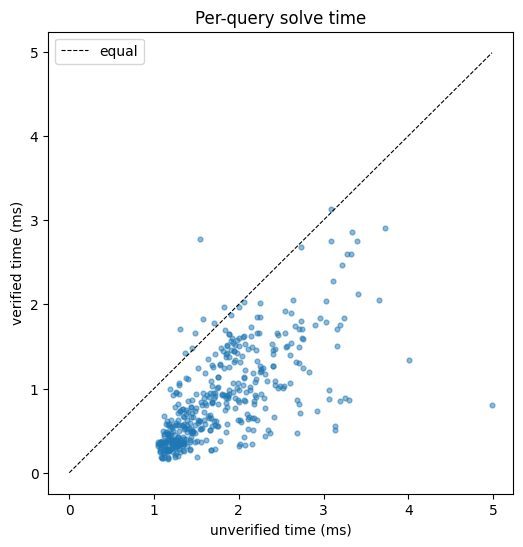

In [6]:
both = df[df.u_time.notna() & df.v_time.notna()].copy()
print(f"{len(both)} queries with both timings")
print(both[["u_time", "v_time"]].describe())

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(both.u_time * 1e3, both.v_time * 1e3, s=12, alpha=0.5)
lim = max(both.u_time.max(), both.v_time.max()) * 1e3
ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="equal")
ax.set_xlabel("unverified time (ms)")
ax.set_ylabel("verified time (ms)")
ax.set_title("Per-query solve time")
ax.legend()
plt.show()

## Inspect a raw record

Use this to eyeball the actual SMT queries / GIL expressions for any row.

In [7]:
def show(i):
    r = records[i]
    print(f"benchmark: {r['argv'][-1]}  session={r['session_id']}  query={r['query_id']}")
    print(f"unverified: {r['unverified'].get('sat_result')}  verified: {r['verified'].get('sat_result')}")
    print("\n--- expressions ---")
    print(json.dumps(r["expressions"], indent=1))
    if r["verified"].get("smt_query"):
        print("\n--- verified smt_query ---")
        print("\n".join(r["verified"]["smt_query"]))

show(0)

benchmark: ./Gillian-JS/Examples/JaVerT/BST.js  session=1780393981.472225  query=0
unverified: sat  verified: None

--- expressions ---
[
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#t"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Empty"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#t"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Nono"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#this"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Empty"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#this"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Nono"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "UnOp",
    [
     "TypeOf"
    ],
    [
     "LVar",
     "#t"
    ]
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Type",
     [
      "ListType"
     ]
    ]
   ]
  

## Interesting verified encodings

The certified backend wraps every value in the `Val` dynamic ADT and is conservative about partial / typed operations, so its SMT often carries machinery the legacy encoder never emits. Two things to hunt for:

1. **Casts out of the `Val` wrapper** — recognizers (`is-list`, `is-bool`, …) and accessors (`getList`, `getRat`, …) that project a dynamic `Val` down to a concrete sort, plus the rational-as-quotient encoding `∃ x x0. p = (to_real x) / (to_real x0)` that casts an `Int` pair into a `Real`.
2. **Extra side conditions** the unverified encoding doesn't generate — quantified element well-formedness (`forall i. 0≤i<len ⇒ …`), non-negativity guards (`>= 0`), and generally many more `(not (= …))` disequality guards, e.g. from guarding partial operations.

The cells below build a per-query feature table (`vq`) over the 441 verified queries, then print curated picks. Everything is a normal dataframe + helper, so re-sort/filter `vq` however you like.

In [8]:
import re

# --- helpers over a single record -------------------------------------------
def _assert_lines(query):
    """Just the (declare-const / (assert / check-sat lines, dropping the shared preamble."""
    return [ln for ln in (query or [])
            if ln.lstrip().startswith(("(declare-const", "(assert", "check-sat", "(check-sat"))]

def _assert_text(query):
    return "\n".join(ln for ln in (query or []) if ln.lstrip().startswith("(assert"))

def n_asserts(query):
    return sum(1 for ln in (query or []) if ln.lstrip().startswith("(assert"))

# Val ADT projection functions (accessors) and recognizers
VAL_ACCESSORS  = ["getLoc", "getBool", "getNat", "getRat", "getStr", "getList"]
VAL_RECOGNIZERS = ["is-loc", "is-bool", "is-nat", "is-rat", "is-string",
                   "is-list", "is-null", "is-none", "is-empty"]

def features(r):
    v = _assert_text(r["verified"]["smt_query"])
    u = _assert_text(r["unverified"]["smt_query"])
    casts = [a for a in VAL_ACCESSORS if a in v]
    recs_used = [a for a in VAL_RECOGNIZERS if a in v]
    return {
        "n_v_assert": n_asserts(r["verified"]["smt_query"]),
        "n_u_assert": n_asserts(r["unverified"]["smt_query"]),
        "casts": casts,
        "recognizers": recs_used,
        "n_exists": v.count("exists"),
        "n_forall": v.count("forall"),
        "n_implies": v.count("=>"),
        # rational cast: Int pair projected into a Real via to_real division
        "rational_quotient": ("to_real" in v and "/" in v),
        # quantified element well-formedness guard over a list's indices
        "list_wf_guard": ("is-list" in v and "forall" in v),
        # extra disequality guards relative to the legacy encoding
        "extra_diseq": v.count("(not (= ") - u.count("(not (= "),
    }

vq = pd.DataFrame([{"idx": i, "benchmark": r["argv"][-1].split("/")[-1],
                    "session_id": r["session_id"], "query_id": r["query_id"],
                    **features(r)}
                   for i, r in enumerate(records) if r["verified"].get("smt_query")])
vq["assert_delta"]  = vq.n_v_assert - vq.n_u_assert
vq["uses_cast"]     = vq.casts.str.len().gt(0) | vq.recognizers.str.len().gt(0) | vq.rational_quotient
vq["verified_recs"] = [records[i] for i in vq.idx]   # back-reference to the full record

print(f"{len(vq)} verified queries")
print(f"  use a Val cast/recognizer/quotient : {vq.uses_cast.sum()}")
print(f"  rational quotient encoding          : {vq.rational_quotient.sum()}")
print(f"  quantified list well-formedness     : {vq.list_wf_guard.sum()}")
print(f"  add disequality guards vs unverified: {(vq.extra_diseq > 0).sum()}")
vq.drop(columns=["verified_recs"]).head()

441 verified queries
  use a Val cast/recognizer/quotient : 175
  rational quotient encoding          : 84
  quantified list well-formedness     : 150
  add disequality guards vs unverified: 303


,idx,benchmark,session_id,query_id,n_v_assert,n_u_assert,casts,recognizers,n_exists,n_forall,n_implies,rational_quotient,list_wf_guard,extra_diseq,assert_delta,uses_cast
0,2,BST.js,1780393981.472225,2,2,2,[],[],0,0,0,False,False,2,0,False
1,3,BST.js,1780393981.472225,3,1,1,[],[],0,0,0,False,False,0,0,False
2,4,BST.js,1780393981.472225,4,4,4,[getList],[is-list],0,1,1,False,True,0,0,True
3,29,BST.js,1780393981.472225,29,4,4,[getList],[is-list],0,1,1,False,True,0,0,True
4,32,BST.js,1780393981.472225,32,4,4,[getList],[is-list],0,1,1,False,True,0,0,True


In [9]:
def show_query(r, show_preamble=False):
    """Print GIL expressions + both backends' SMT assertions for one record."""
    print("=" * 72)
    print(f"{r['argv'][-1]}   session={r['session_id']} query={r['query_id']}")
    print(f"unverified={r['unverified']['sat_result']}  verified={r['verified']['sat_result']}")
    print("=" * 72)
    print("\n--- GIL expressions ---")
    print(json.dumps(r["expressions"], indent=1))
    for backend in ("unverified", "verified"):
        q = r[backend]["smt_query"]
        q = q if show_preamble else _assert_lines(q)
        print(f"\n--- {backend.upper()} ---")
        print("\n".join(q))

def show_rows(frame, show_preamble=False):
    """Print every record referenced by a slice of vq."""
    for rec in frame["verified_recs"]:
        show_query(rec, show_preamble)
        print()

### Picks 1 — casts out of the `Val` wrapper

A `TypeOf(x) == ListType` check: the legacy encoder builds a 12-way nested `ite` over the `Extended_GIL_Literal` recognizers, whereas the verified encoder casts via `is-list` + `getList` and tacks on a `forall` over the list's indices. And a rational comparison where the verified side encodes the `Num` as a quotient of two `to_real`-cast integers with a non-negativity guard.

In [10]:
# Smallest query that casts via is-list/getList (clearest to read), and the
# smallest rational-quotient cast. Sort by assertion count so picks stay readable.
vq["_size"] = vq.n_v_assert

list_cast = vq[vq.recognizers.apply(lambda r: "is-list" in r)].sort_values("_size")
rational  = vq[vq.rational_quotient].sort_values("_size")

print("### list cast (is-list + getList) — clearest example\n")
show_rows(list_cast.head(1))
print("\n\n### rational quotient cast (to_real Int -> Real)\n")
show_rows(rational.head(1))

### list cast (is-list + getList) — clearest example

./wisl/examples/DLL_recursive.wisl   session=1780396759.088880 query=18
unverified=sat  verified=sat

--- GIL expressions ---
[
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "UnOp",
    [
     "TypeOf"
    ],
    [
     "LVar",
     "#v_a"
    ]
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Type",
     [
      "ListType"
     ]
    ]
   ]
  ]
 ]
]

--- UNVERIFIED ---
(declare-const $$v_a Extended_GIL_Literal)
(assert
 (not
  (=
   (ite (isSet $$v_a) SetType
    (ite (isList (singElem $$v_a)) ListType
     (ite (isType (singElem $$v_a)) TypeType
      (ite (isLoc (singElem $$v_a)) ObjectType
       (ite (isString (singElem $$v_a)) StringType
        (ite (isNum (singElem $$v_a)) NumberType
         (ite (isInt (singElem $$v_a)) IntType
          (ite (isBool (singElem $$v_a)) BooleanType
           (ite (isNone (singElem $$v_a)) NoneType
            (ite (isUndefined (singElem $$v_a)) UndefinedType
             (

### Picks 2 — extra side conditions the unverified encoding never generates

Ranked by how many more assertions the verified query carries than the legacy one. The top of this list is dominated by `PriQ.js` (priority-queue) queries, where the verified encoding piles on quantified well-formedness and ordering guards over the heap's list representation — `+22` assertions vs the legacy `16`.

In [11]:
# Leaderboard of verified queries carrying the most extra assertions.
cols = ["benchmark", "query_id", "n_v_assert", "n_u_assert", "assert_delta",
        "n_forall", "n_exists", "n_implies", "extra_diseq", "casts"]
top_side = vq.sort_values("assert_delta", ascending=False)
top_side[cols].head(12)

,benchmark,query_id,n_v_assert,n_u_assert,assert_delta,n_forall,n_exists,n_implies,extra_diseq,casts
121,PriQ.js,55,38,16,22,3,22,3,0,[getList]
96,PriQ.js,30,38,16,22,3,22,3,0,[getList]
118,PriQ.js,52,38,16,22,3,22,3,0,[getList]
99,PriQ.js,33,38,16,22,3,22,3,0,[getList]
119,PriQ.js,53,36,16,20,3,20,3,0,[getList]
120,PriQ.js,54,36,16,20,3,20,3,0,[getList]
101,PriQ.js,35,36,16,20,3,20,3,0,[getList]
100,PriQ.js,34,36,16,20,3,20,3,0,[getList]
97,PriQ.js,31,36,16,20,3,20,3,0,[getList]
98,PriQ.js,32,36,16,20,3,20,3,0,[getList]


In [12]:
# Print the single most side-condition-heavy query in full (both backends).
show_rows(top_side.head(2))

./Gillian-JS/Examples/JaVerT/PriQ.js   session=1780394078.336952 query=55
unverified=sat  verified=sat

--- GIL expressions ---
[
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#lvar_789"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Empty"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#lvar_789"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Nono"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#lvar_790"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Empty"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#lvar_790"
   ],
   [
    "Equal"
   ],
   [
    "Lit",
    [
     "Nono"
    ]
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#npri"
   ],
   [
    "Equal"
   ],
   [
    "LVar",
    "#pri_nl"
   ]
  ]
 ],
 [
  "UnOp",
  [
   "Not"
  ],
  [
   "BinOp",
   [
    "LVar",
    "#n

### Are any list `forall` guards non-trivial?

The list well-formedness guard has shape `forall i. 0≤i<len ⇒ BODY`. Does `BODY` ever constrain the *elements* (anything other than `true`)? Scan every `(=> A B)` across all verified queries and tabulate the consequents.

In [13]:
# Is the list forall guard's RHS ever non-trivial?
# The guard shape is:  forall i. (0<=i & i<len)  =>  BODY
# Scan every (=> A B) across all verified queries and tabulate the consequent B.
from collections import Counter

def implies_operands(text):
    """Yield (antecedent, consequent) for each top-level (=> A B) in text."""
    out = []
    i = 0
    while (j := text.find("(=>", i)) >= 0:
        i = j + 3
        ops, k = [], i
        while len(ops) < 2 and k < len(text):
            while k < len(text) and text[k] in " \n\t":
                k += 1
            if k >= len(text):
                break
            if text[k] == "(":                      # balanced s-expr
                depth, s = 0, k
                while k < len(text):
                    depth += (text[k] == "(") - (text[k] == ")")
                    k += 1
                    if depth == 0:
                        break
                ops.append(text[s:k])
            else:                                    # bare atom
                s = k
                while k < len(text) and text[k] not in " \n\t()":
                    k += 1
                ops.append(text[s:k])
        if len(ops) == 2:
            out.append((ops[0], ops[1]))
    return out

bodies = Counter()
nontrivial = []
for i, r in enumerate(records):
    q = r["verified"].get("smt_query")
    if not q:
        continue
    txt = _assert_text(q)
    for ante, cons in implies_operands(txt):
        body = re.sub(r"\s+", " ", cons).strip()
        bodies[body] += 1
        if body != "true" and "seq.len" in ante:    # list-bounds guarded, non-trivial body
            nontrivial.append((i, r["argv"][-1].split("/")[-1], r["query_id"], body))

print(f"total (=> ...) consequents across verified queries: {sum(bodies.values())}")
print("distinct consequents:", dict(bodies))
print(f"\nlist-bounds foralls with a non-`true` RHS: {len(nontrivial)}")
if nontrivial:
    show_query(records[nontrivial[0][0]])
else:
    print("=> none. Every list well-formedness guard is `forall i. 0<=i<len => true` "
          "(vacuous). The encoder constrains the index range but never the elements.")

total (=> ...) consequents across verified queries: 477
distinct consequents: {'true': 477}

list-bounds foralls with a non-`true` RHS: 0
=> none. Every list well-formedness guard is `forall i. 0<=i<len => true` (vacuous). The encoder constrains the index range but never the elements.
